In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import utils
import random

audio_paths = [
    "../music-clips/classical_1_60s.wav",
    # "../music-clips/classical_1_30s.wav",
    # "../music-clips/classical_1_10s.wav",
    "../music-clips/electronic_5_60s.wav",
    "../music-clips/cicadas_57s.wav",
    # "../music-clips/electronic_10.wav",
    "../music-clips/guitar_melody_131s.wav",

    "../music-clips/beep_30s.wav",
    "../music-clips/crickets_6s.wav",
    "../music-clips/metronome_60s.wav",
    # "../music-clips/sa01.wav",
    # "../music-clips/sa02.wav",
    ]

model, processor = utils.load_music_gen_model()
wfs = utils.load_process_bulk_audio(audio_paths, sr=32000)
inputs_dict = utils.process_bulk_music_gen(wfs, processor=processor)

attentions_dict = utils.extract_attentions(model, inputs_dict)

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

In [ ]:
mad_dict = utils.compute_mad_dict(attentions_dict)

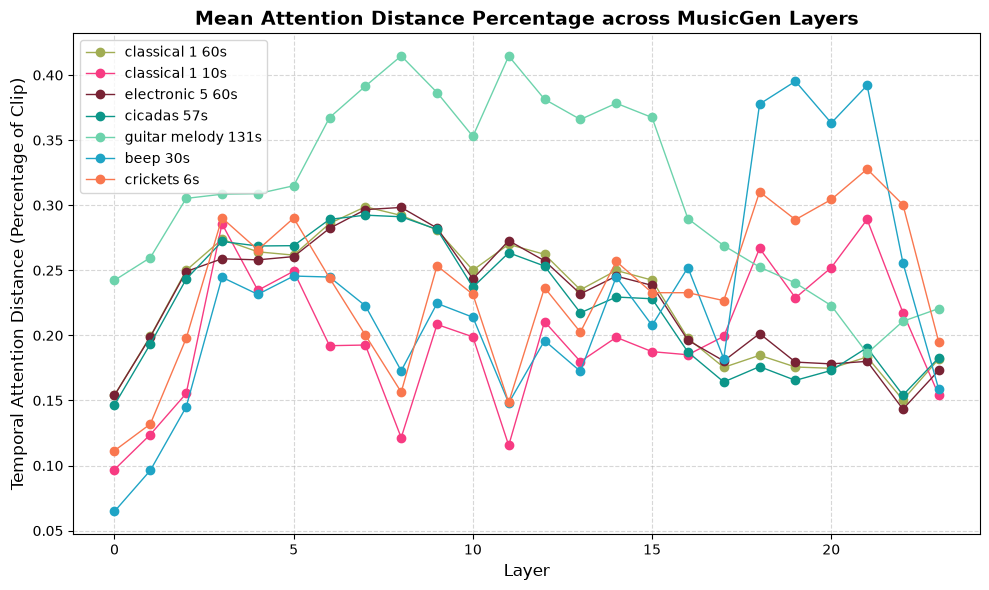

In [ ]:
plt.figure(figsize=(10, 6))

for path, mads in mad_dict.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(mad_dict.get(path))
    layer_averages = np.mean(mads, axis=1)
    label = path.replace("../music-clips/", "").replace("_", " ").replace(".wav", "")
    plt.plot(range(num_layers), layer_averages, color=random_hex, linewidth=1, marker='o', label=label)

plt.title("Mean Attention Distance Percentage across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Temporal Attention Distance (Percentage of Clip)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(),
plt.tight_layout()

In [ ]:
entropies = {}
for path, attns in attentions_dict.items():
    entropy = utils.compute_relative_attention_entropy(torch.stack(attns).squeeze(dim=1))
    entropies[path] = entropy

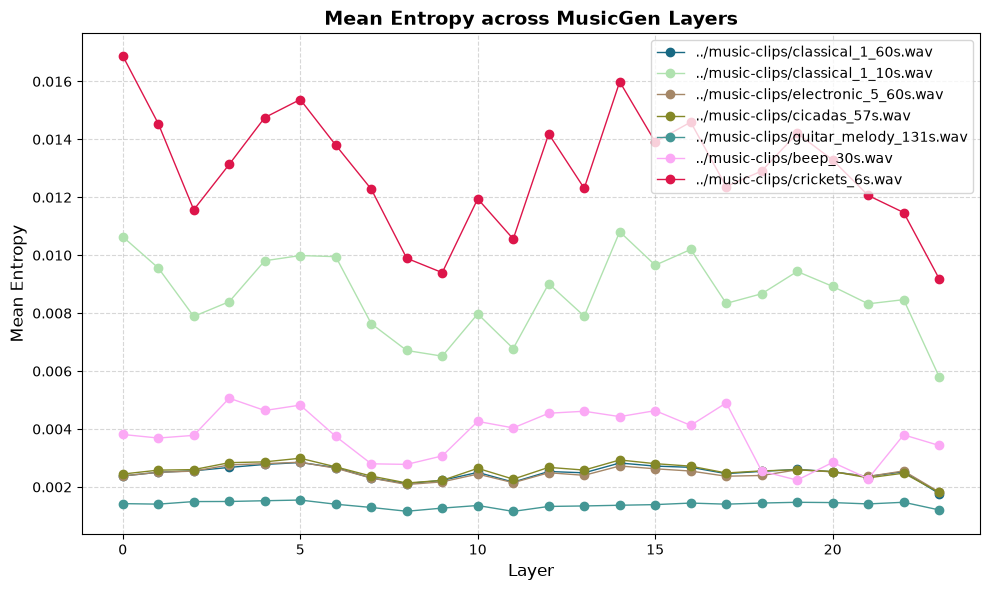

In [ ]:
plt.figure(figsize=(10, 6))

for path, ent in entropies.items():
    random_hex = f"#{random.randint(0, 0xFFFFFF):06x}"
    num_layers = len(entropies.get(path))
    layer_averages = np.mean(ent.numpy(), axis=1)
    plt.plot(range(num_layers), layer_averages, color=random_hex, linewidth=1, marker='o', label=path)

plt.title("Mean Entropy across MusicGen Layers", fontsize=14, fontweight='bold')
plt.xlabel("Layer", fontsize=12)
plt.ylabel("Mean Entropy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

In [ ]:
def compute_dynamic_mad_over_time(attention_matrix, frame_rate_hz=50.0):
    """
    attention_matrix: shape [seq_len, seq_len] for a SPECIFIC layer and head (or layer mean)
    returns: [seq_len] array of MAD in seconds for each frame
    """
    seq_len = attention_matrix.shape[0]
    indices = torch.arange(seq_len, device=attention_matrix.device).float()
    
    # Distance matrix D[i, j] = |i - j| / frame_rate
    dist_matrix = torch.abs(indices.unsqueeze(0) - indices.unsqueeze(1)) / frame_rate_hz
    
    # MAD for query i = dot_product(A[i, :], dist_matrix[i, :])
    mad_t = torch.sum(attention_matrix * dist_matrix, dim=-1) # Shape: [seq_len]
    return mad_t

clip1_path = "../music-clips/classical_1_60s.wav"
clip2_path = "../music-clips/metronome_60s.wav"
# --- Plotting Example ---
# Average across heads for Layer 19 (where sa01/sa02 spiked in your MusicGen plot!)
for layer_idx in range(24):
    attn_matrix_clip1 = attentions_dict[clip1_path][layer_idx].squeeze(dim=0).mean(dim=0) # [seq_len, seq_len]
    attn_matrix_clip2  = attentions_dict[clip2_path][layer_idx].squeeze(dim=0).mean(dim=0)

    frames = min(attn_matrix_clip1.shape[-1], attn_matrix_clip2.shape[-1])
    mad_t_music = compute_dynamic_mad_over_time(attn_matrix_clip1).cpu().numpy()[:frames]
    mad_t_sa01  = compute_dynamic_mad_over_time(attn_matrix_clip2).cpu().numpy()[:frames]

    time_axis = torch.arange(frames) / 50.0 # Convert frames to seconds

    plt.figure(figsize=(12, 4))
    plt.plot(time_axis, mad_t_music, label=f"{clip1_path.replace('../music-clips/', '').replace('.wav', '')} L{layer_idx}", alpha=0.8)
    plt.plot(time_axis, mad_t_sa01, label=f"{clip2_path.replace('../music-clips/', '').replace('.wav', '')} L{layer_idx}", color='orange', alpha=0.8)
    plt.xlabel("Audio Timestamp (Seconds)")
    plt.ylabel("Temporal Attention Distance (Seconds)")
    plt.title(f"Dynamic Mean Attention Distance over Time (Layer {layer_idx})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

KeyError: '../music-clips/metronome_60s.wav'